In [17]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import streamlit as st
import re


In [10]:
import undetected_chromedriver as uc
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import pandas as pd
import time


def scrape_udemy(pages=5):

    options = uc.ChromeOptions()
    options.add_argument("--window-size=1920,1080")

    driver = uc.Chrome(options=options, version_main=145)

    all_courses = []

    try:

        for page in range(205, pages + 1):

            url = f"https://www.udemy.com/courses/it-and-software/it-certification/?p={page}"

            print(f"\nScraping Page {page}")
            driver.get(url)

            wait = WebDriverWait(driver, 20)

            time.sleep(5)

            driver.execute_script("window.scrollTo(0,1000)")
            time.sleep(3)

            cards = wait.until(
                EC.presence_of_all_elements_located(
                    (By.CSS_SELECTOR, "div[class*='course-card_container']")
                )
            )

            print(f"Found {len(cards)} courses")

            for card in cards:

                try:
                    title = card.find_element(
                        By.CSS_SELECTOR,
                        "h3[data-purpose='course-title-url']"
                    ).text
                except:
                    title = ""

                try:
                    description = card.find_element(
                        By.CSS_SELECTOR,
                        "p[data-purpose*='course-headline']"
                    ).text
                except:
                    description = ""

                try:
                    instructor = card.find_element(
                        By.CSS_SELECTOR,
                        "div[class*='instructor-list']"
                    ).text
                except:
                    instructor = ""

                try:
                    rating = card.find_element(
                        By.CSS_SELECTOR,
                        "div[class*='course-card-ratings']"
                    ).text
                except:
                    rating = ""

                try:
                    price = card.find_element(
                        By.CSS_SELECTOR,
                        "div[class*='price-text-container']"
                    ).text
                except:
                    price = ""

                try:
                    details = card.find_element(
                        By.CSS_SELECTOR,
                        "div[class*='course-card-details']"
                    ).text
                except:
                    details = ""

                course = {
                    "Title": title,
                    "Description": description,
                    "Instructor": instructor,
                    "Rating": rating,
                    "Price": price,
                    "Details": details,
                    "Page": page
                }

                all_courses.append(course)

            df = pd.DataFrame(all_courses)
            df.to_csv("udemy_courses.csv", index=False)

            print(f"Saved data up to page {page}")

    finally:
        driver.quit()

    print("\nScraping Finished")


if __name__ == "__main__":
    scrape_udemy(pages=400)


Scraping Page 205
Found 20 courses
Saved data up to page 205

Scraping Page 206
Found 16 courses
Saved data up to page 206

Scraping Page 207
Found 16 courses
Saved data up to page 207

Scraping Page 208
Found 16 courses
Saved data up to page 208

Scraping Page 209
Found 16 courses
Saved data up to page 209

Scraping Page 210
Found 16 courses
Saved data up to page 210

Scraping Page 211
Found 16 courses
Saved data up to page 211

Scraping Page 212
Found 16 courses
Saved data up to page 212

Scraping Page 213
Found 16 courses
Saved data up to page 213

Scraping Page 214
Found 16 courses
Saved data up to page 214

Scraping Page 215
Found 16 courses
Saved data up to page 215

Scraping Page 216
Found 16 courses
Saved data up to page 216

Scraping Page 217
Found 16 courses
Saved data up to page 217

Scraping Page 218
Found 16 courses
Saved data up to page 218

Scraping Page 219
Found 16 courses
Saved data up to page 219

Scraping Page 220
Found 16 courses
Saved data up to page 220

Scrapin

In [5]:
import undetected_chromedriver as uc
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import pandas as pd
import time


def scrape_coursera(pages=5):

    options = uc.ChromeOptions()
    options.add_argument("--window-size=1920,1080")

    driver = uc.Chrome(options=options, version_main=145)

    all_courses = []

    try:

        for page in range(1, pages + 1):

            url = f"https://www.coursera.org/search?page={page}&sortBy=BEST_MATCH"
            print(f"\nScraping Page {page}")

            driver.get(url)

            wait = WebDriverWait(driver, 30)

            time.sleep(5)

            driver.execute_script("window.scrollTo(0, document.body.scrollHeight)")
            time.sleep(3)

            cards = wait.until(
                EC.presence_of_all_elements_located(
                    (By.CSS_SELECTOR, "div.cds-ProductCard-gridCard")
                )
            )

            print(f"Found {len(cards)} courses")

            for card in cards:

                try:
                    title = card.find_element(By.CSS_SELECTOR, "h3").text
                except:
                    title = ""

                try:
                    partner = card.find_element(
                        By.CSS_SELECTOR,
                        "p.cds-ProductCard-partnerNames"
                    ).text
                except:
                    partner = ""

                try:
                    description = card.find_element(By.XPATH, ".//p[contains(text(),'Skills')]").text
                except:
                    description = ""

                try:
                    rating_reviews = card.find_element(By.XPATH, ".//*[contains(text(),'reviews')]").text
                except:
                    rating_reviews = ""

                try:
                    details = card.find_element(By.XPATH, ".//div[contains(@class,'metadata')]").text
                except:
                    details = ""

                try:
                    link = card.find_element(By.CSS_SELECTOR, "a").get_attribute("href")
                except:
                    link = ""

                course = {
                    "Title": title,
                    "Partner": partner,
                    "Description": description,
                    "Rating_Reviews": rating_reviews,
                    "Details": details,
                    "URL": link,
                    "Page": page
                }

                all_courses.append(course)

            df = pd.DataFrame(all_courses)
            df.to_csv("coursera_courses.csv", index=False)

            print(f"Saved data up to page {page}")

    finally:
        driver.quit()

    print("\nScraping Finished")


if __name__ == "__main__":
    scrape_coursera(pages=300)


Scraping Page 1
Found 12 courses
Saved data up to page 1

Scraping Page 2
Found 12 courses
Saved data up to page 2

Scraping Page 3
Found 12 courses
Saved data up to page 3

Scraping Page 4
Found 12 courses
Saved data up to page 4

Scraping Page 5
Found 12 courses
Saved data up to page 5

Scraping Page 6
Found 12 courses
Saved data up to page 6

Scraping Page 7
Found 12 courses
Saved data up to page 7

Scraping Page 8
Found 12 courses
Saved data up to page 8

Scraping Page 9
Found 12 courses
Saved data up to page 9

Scraping Page 10
Found 12 courses
Saved data up to page 10

Scraping Page 11
Found 12 courses
Saved data up to page 11

Scraping Page 12
Found 12 courses
Saved data up to page 12

Scraping Page 13
Found 12 courses
Saved data up to page 13

Scraping Page 14
Found 12 courses
Saved data up to page 14

Scraping Page 15
Found 12 courses
Saved data up to page 15

Scraping Page 16
Found 12 courses
Saved data up to page 16

Scraping Page 17
Found 12 courses
Saved data up to page 1

### Load CSV  Data

In [3]:
udemy = pd.read_csv("udemy_courses.csv")
coursera = pd.read_csv("coursera_courses.csv")

In [4]:
udemy.head()

,Title,Description,Instructor,Rating,Price,Details,Page
0,Ultimate AWS Certified Solutions Architect Ass...,Full Practice Exam | Learn Cloud Computing | P...,Stephane Maarek | AWS Certified Cloud Practiti...,"Rating: 4.7 out of 5\n4.7\n(284,237)",Current price\n$89.99,27 total hours\n398 lectures\nAll Levels,1
1,[NEW] Ultimate AWS Certified Cloud Practitione...,Full Practice Exam included + explanations | L...,Stephane Maarek | AWS Certified Cloud Practiti...,"Rating: 4.7 out of 5\n4.7\n(283,029)",Current price\n$89.99,14.5 total hours\n282 lectures\nBeginner,1
2,Master Microsoft Azure Fundamentals: AZ-900 Ex...,Comprehensive AZ-900 Training with Practice Te...,"Scott Duffy • 1.000.000+ Students, Software Ar...","Rating: 4.6 out of 5\n4.6\n(137,995)",Current price\n$79.99,8.5 total hours\n87 lectures\nBeginner,1
3,Ultimate AWS Certified Developer Associate 202...,Full Practice Exam with Explanations included!...,Stephane Maarek | AWS Certified Cloud Practiti...,"Rating: 4.7 out of 5\n4.7\n(120,868)",Current price\n$79.99,32 total hours\n454 lectures\nAll Levels,1
4,CompTIA Security+ (SY0-701) Complete Course & ...,CompTIA Security+ (SY0-701) Bootcamp - Your pr...,Jason Dion • 2.8 Million+ Enrollments Worldwid...,"Rating: 4.7 out of 5\n4.7\n(115,138)",Current price\n$79.99,31 total hours\n264 lectures\nAll Levels,1


In [5]:
coursera.head()

,Title,Partner,Description,Rating_Reviews,Details,URL,Page
0,Google AI,Google,NaN,1K reviews,Beginner · Professional Certificate · 3 - 6 Mo...,https://www.coursera.org/professional-certific...,1
1,Google AI Essentials,Google,NaN,20K reviews,Beginner · Specialization · 3 - 6 Months,https://www.coursera.org/specializations/ai-es...,1
2,Google Data Analytics,Google,"Skills you'll gain: Data Storytelling, Rmarkdo...",178K reviews,Beginner · Professional Certificate · 3 - 6 Mo...,https://www.coursera.org/professional-certific...,1
3,Google Project Management,Google,"Skills you'll gain: Quality Management, Projec...",141K reviews,Beginner · Professional Certificate · 3 - 6 Mo...,https://www.coursera.org/professional-certific...,1
4,Google Cybersecurity,Google,"Skills you'll gain: Threat Modeling, Network S...",65K reviews,Beginner · Professional Certificate · 3 - 6 Mo...,https://www.coursera.org/professional-certific...,1


In [6]:
udemy.describe

<bound method NDFrame.describe of                                                   Title  \
0     Ultimate AWS Certified Solutions Architect Ass...   
1     [NEW] Ultimate AWS Certified Cloud Practitione...   
2     Master Microsoft Azure Fundamentals: AZ-900 Ex...   
3     Ultimate AWS Certified Developer Associate 202...   
4     CompTIA Security+ (SY0-701) Complete Course & ...   
...                                                 ...   
6796  C_CPI_2506 SAP Certified Associate - Integrati...   
6797  Learn Oracle NetSuite Script: User Event & Sch...   
6798  Sitecore XM Cloud Developer Certification Exam...   
6799  The Official ISACA CISM Certification Practice...   
6800  Practice AWS Certified Solutions Architect – A...   

                                            Description  \
0     Full Practice Exam | Learn Cloud Computing | P...   
1     Full Practice Exam included + explanations | L...   
2     Comprehensive AZ-900 Training with Practice Te...   
3     Full Practice E

In [7]:
coursera.describe

<bound method NDFrame.describe of                                                   Title  \
0                                             Google AI   
1                                  Google AI Essentials   
2                                 Google Data Analytics   
3                             Google Project Management   
4                                  Google Cybersecurity   
...                                                 ...   
3595              Business Strategies for Social Impact   
3596  Human Resources Management Capstone: HR for Pe...   
3597         AWS Developer Associate Certification Prep   
3598                 Neural Networks and Random Forests   
3599                 Machine Learning Models in Science   

                         Partner  \
0                         Google   
1                         Google   
2                         Google   
3                         Google   
4                         Google   
...                          ...   
3595 

In [8]:
udemy.dtypes

Title          object
Description    object
Instructor     object
Rating         object
Price          object
Details        object
Page            int64
dtype: object

In [9]:
coursera.dtypes

Title             object
Partner           object
Description       object
Rating_Reviews    object
Details           object
URL               object
Page               int64
dtype: object

In [10]:
# --- CLEAN UDEMY DATA ---
udemy["Platform"] = "Udemy"

udemy = udemy.rename(columns={
    "Instructor": "Instructor_Partner"
})

udemy["URL"] = ""
udemy["Reviews"] = ""

In [11]:
# --- CLEAN COURSERA DATA ---
coursera["Platform"] = "Coursera"

coursera = coursera.rename(columns={
    "Partner": "Instructor_Partner",
    "Rating_Reviews": "Reviews"
})

coursera["Price"] = ""

In [12]:
# --- ALIGN COLUMNS ---
columns = [
    "Platform",
    "Title",
    "Instructor_Partner",
    "Description",
    "Rating",
    "Reviews",
    "Price",
    "Details",
    "URL"
]

udemy = udemy.reindex(columns=columns)
coursera = coursera.reindex(columns=columns)

In [15]:
combined = pd.concat([udemy, coursera], ignore_index=True)

In [16]:
# save new dataset
combined.to_csv("all_courses.csv", index=False)

print("Combined dataset created!")
print(combined.head())

Combined dataset created!
  Platform                                              Title  \
0    Udemy  Ultimate AWS Certified Solutions Architect Ass...   
1    Udemy  [NEW] Ultimate AWS Certified Cloud Practitione...   
2    Udemy  Master Microsoft Azure Fundamentals: AZ-900 Ex...   
3    Udemy  Ultimate AWS Certified Developer Associate 202...   
4    Udemy  CompTIA Security+ (SY0-701) Complete Course & ...   

                                  Instructor_Partner  \
0  Stephane Maarek | AWS Certified Cloud Practiti...   
1  Stephane Maarek | AWS Certified Cloud Practiti...   
2  Scott Duffy • 1.000.000+ Students, Software Ar...   
3  Stephane Maarek | AWS Certified Cloud Practiti...   
4  Jason Dion • 2.8 Million+ Enrollments Worldwid...   

                                         Description  \
0  Full Practice Exam | Learn Cloud Computing | P...   
1  Full Practice Exam included + explanations | L...   
2  Comprehensive AZ-900 Training with Practice Te...   
3  Full Practice Exam 

In [19]:
df = pd.read_csv("all_courses.csv")

# remove newline characters and extra spaces from all text columns
df = df.applymap(lambda x: re.sub(r'\s+', ' ', str(x)).strip() if isinstance(x, str) else x)

C:\Users\USER-PC\AppData\Local\Temp\ipykernel_360\2129428462.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: re.sub(r'\s+', ' ', str(x)).strip() if isinstance(x, str) else x)


In [20]:
# -------- CLEAN RATING --------
def clean_rating(value):
    if pd.isna(value):
        return ""
    
    # find rating like 4.7
    match = re.search(r'(\d\.\d)', value)
    return match.group(1) if match else ""

df["Rating"] = df["Rating"].apply(clean_rating)


In [21]:
# -------- CLEAN REVIEWS --------
def clean_reviews(value):
    if pd.isna(value):
        return ""
    
    # get numbers inside brackets or text like 284,237
    match = re.search(r'([\d,]+)', value)
    if match:
        return int(match.group(1).replace(",", ""))
    
    return ""

df["Reviews"] = df["Reviews"].apply(clean_reviews)


In [22]:
# -------- CLEAN PRICE --------
def clean_price(value):
    if pd.isna(value):
        return ""
    
    match = re.search(r'\$?(\d+\.?\d*)', value)
    return match.group(1) if match else ""

df["Price"] = df["Price"].apply(clean_price)


In [24]:
# -------- CLEAN DETAILS --------
df["Details"] = df["Details"].str.replace("total hours", "hours", regex=False)
df["Details"] = df["Details"].str.strip()


In [26]:
df = pd.read_csv("all_courses.csv")

# replace newline characters with space
for col in df.columns:
    df[col] = df[col].astype(str).str.replace("\n", " ").str.replace("\r", " ").str.strip()

# remove multiple spaces
df = df.replace(r"\s+", " ", regex=True)

# save back to the SAME file
df.to_csv("all_courses.csv", index=False)

print("Cleaning complete and saved to all_courses.csv")

Cleaning complete and saved to all_courses.csv


## Analysis

In [30]:
df = pd.read_csv("all_courses_clean.csv")

print(df.head())


  Platform                                              Title  \
0    Udemy  Ultimate AWS Certified Solutions Architect Ass...   
1    Udemy  [NEW] Ultimate AWS Certified Cloud Practitione...   
2    Udemy  Master Microsoft Azure Fundamentals: AZ-900 Ex...   
3    Udemy  Ultimate AWS Certified Developer Associate 202...   
4    Udemy  CompTIA Security+ (SY0-701) Complete Course & ...   

                                  Instructor_Partner  \
0  Stephane Maarek | AWS Certified Cloud Practiti...   
1  Stephane Maarek | AWS Certified Cloud Practiti...   
2  Scott Duffy • 1.000.000+ Students, Software Ar...   
3  Stephane Maarek | AWS Certified Cloud Practiti...   
4  Jason Dion • 2.8 Million+ Enrollments Worldwid...   

                                         Description  \
0  Full Practice Exam | Learn Cloud Computing | P...   
1  Full Practice Exam included + explanations | L...   
2  Comprehensive AZ-900 Training with Practice Te...   
3  Full Practice Exam with Explanations included

In [31]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10401 entries, 0 to 10400
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Platform            10401 non-null  object
 1   Title               10288 non-null  object
 2   Instructor_Partner  10288 non-null  object
 3   Description         6700 non-null   object
 4   Rating              6688 non-null   object
 5   Reviews             3292 non-null   object
 6   Price               6671 non-null   object
 7   Details             10016 non-null  object
 8   URL                 3600 non-null   object
dtypes: object(9)
memory usage: 731.4+ KB
None


In [32]:
# extract rating
df["Rating_value"] = df["Rating"].str.extract(r'(\d\.\d)').astype(float)

# extract review count
df["Reviews_value"] = df["Rating"].str.extract(r'\(([\d,]+)\)')
df["Reviews_value"] = df["Reviews_value"].str.replace(",", "").astype(float)

# extract price
df["Price_value"] = df["Price"].str.extract(r'(\d+\.?\d*)').astype(float)

# extract hours
df["Hours"] = df["Details"].str.extract(r'(\d+\.?\d*) total hours').astype(float)

# extract lectures
df["Lectures"] = df["Details"].str.extract(r'(\d+) lectures').astype(float)

In [33]:
print("Total courses:", len(df))
print(df["Platform"].value_counts())

Total courses: 10401
Platform
Udemy       6801
Coursera    3600
Name: count, dtype: int64


In [34]:
print("Total courses:", len(df))
print(df["Platform"].value_counts())

Total courses: 10401
Platform
Udemy       6801
Coursera    3600
Name: count, dtype: int64


In [35]:
top_courses = df.sort_values("Reviews_value", ascending=False)

print(top_courses[["Platform","Title","Reviews_value"]].head(10))

     Platform                                              Title  \
0       Udemy  Ultimate AWS Certified Solutions Architect Ass...   
3296    Udemy  Ultimate AWS Certified Solutions Architect Ass...   
4732    Udemy  Ultimate AWS Certified Solutions Architect Ass...   
3956    Udemy  Ultimate AWS Certified Solutions Architect Ass...   
4776    Udemy  Ultimate AWS Certified Solutions Architect Ass...   
4754    Udemy  Ultimate AWS Certified Solutions Architect Ass...   
6287    Udemy  Ultimate AWS Certified Solutions Architect Ass...   
6134    Udemy  Ultimate AWS Certified Solutions Architect Ass...   
1912    Udemy  Ultimate AWS Certified Solutions Architect Ass...   
4797    Udemy  Ultimate AWS Certified Solutions Architect Ass...   

      Reviews_value  
0          284237.0  
3296       284229.0  
4732       284229.0  
3956       284229.0  
4776       284229.0  
4754       284229.0  
6287       284229.0  
6134       284229.0  
1912       284229.0  
4797       284229.0  


In [36]:
print(df["Instructor_Partner"].value_counts().head(10))

Instructor_Partner
IBM                                                                                 189
Coursera                                                                            155
Stephane Maarek | AWS Certified Cloud Practitioner,Solutions Architect,Developer    144
Google                                                                              118
Microsoft                                                                           115
Packt                                                                               113
Google Cloud                                                                        107
University of Pennsylvania                                                          106
University of Michigan                                                              104
Stone River eLearning                                                                97
Name: count, dtype: int64


In [37]:
udemy = df[df["Platform"] == "Udemy"]

print("Average price:", udemy["Price_value"].mean())
print("Max price:", udemy["Price_value"].max())
print("Min price:", udemy["Price_value"].min())

Average price: 36.55999249812454
Max price: 199.99
Min price: 19.99


In [38]:
print(df["Hours"].describe())

count    3057.000000
mean       10.891233
std        14.626341
min         0.500000
25%         3.500000
50%         7.000000
75%        13.500000
max       290.000000
Name: Hours, dtype: float64


In [39]:
df["Level"] = df["Details"].str.extract(r'(Beginner|Intermediate|Advanced|All Levels)')

print(df["Level"].value_counts())

Level
All Levels      3963
Beginner        3609
Intermediate    1864
Advanced          91
Name: count, dtype: int64


In [40]:
df.to_csv("all_courses_clean.csv", index=False)

In [41]:
len(df)

10401

In [42]:
df = df.drop_duplicates()

# check how many rows removed
print("Rows after removing duplicates:", len(df))

# save cleaned dataset
df.to_csv("all_courses_clean.csv", index=False)

print("Duplicate rows removed successfully.")

Rows after removing duplicates: 9722
Duplicate rows removed successfully.


In [44]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


## Visualization

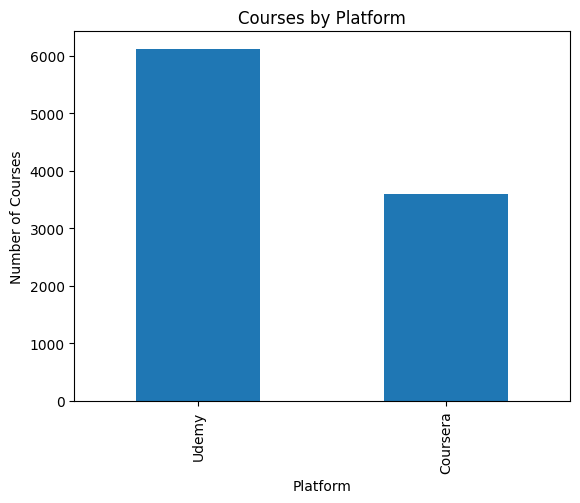

In [ ]:

df["Platform"].value_counts().plot(kind="bar")

plt.title("Courses by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Courses")
plt.show()

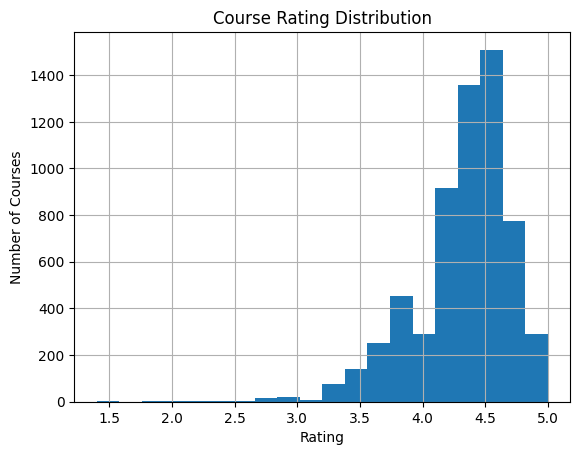

In [46]:
df["Rating_value"] = df["Rating"].str.extract(r'(\d\.\d)').astype(float)

df["Rating_value"].hist(bins=20)

plt.title("Course Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Courses")
plt.show()

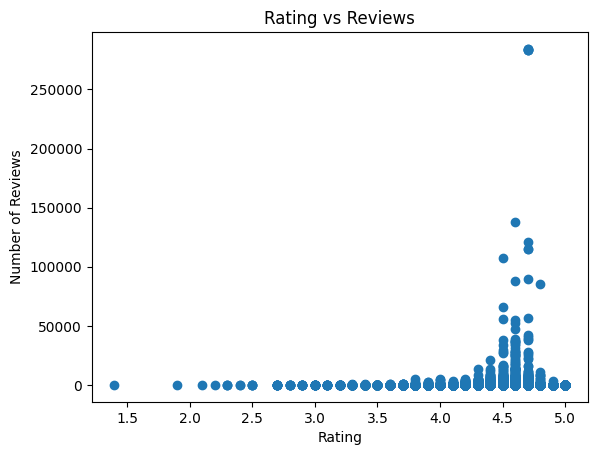

In [47]:
df["Reviews_value"] = df["Rating"].str.extract(r'\(([\d,]+)\)')
df["Reviews_value"] = df["Reviews_value"].str.replace(",", "").astype(float)

plt.scatter(df["Rating_value"], df["Reviews_value"])

plt.title("Rating vs Reviews")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

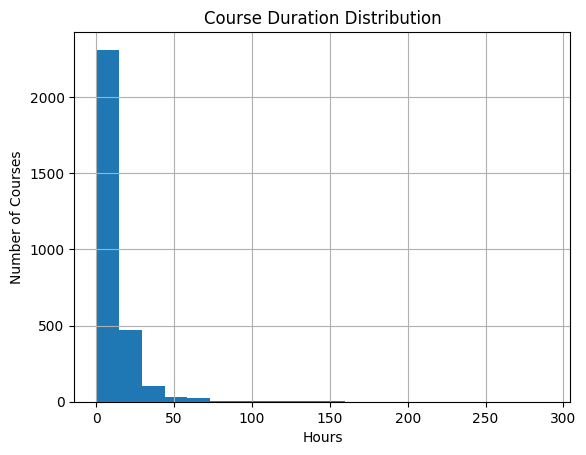

In [48]:
df["Hours"] = df["Details"].str.extract(r'(\d+\.?\d*) total hours').astype(float)

df["Hours"].hist(bins=20)

plt.title("Course Duration Distribution")
plt.xlabel("Hours")
plt.ylabel("Number of Courses")
plt.show()

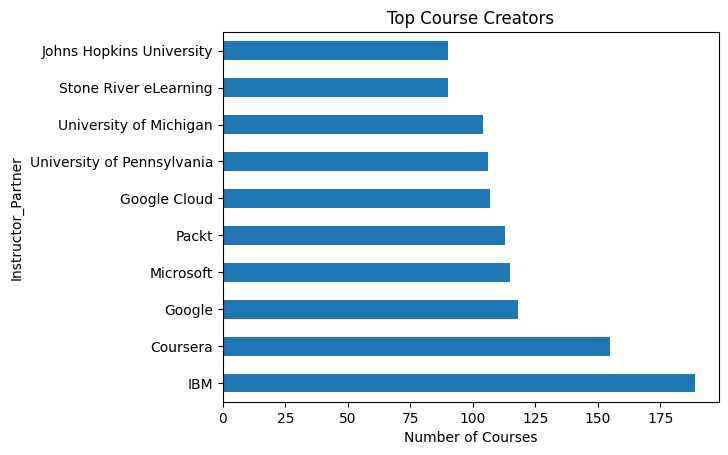

In [49]:
top_instructors = df["Instructor_Partner"].value_counts().head(10)

top_instructors.plot(kind="barh")

plt.title("Top Course Creators")
plt.xlabel("Number of Courses")
plt.show()

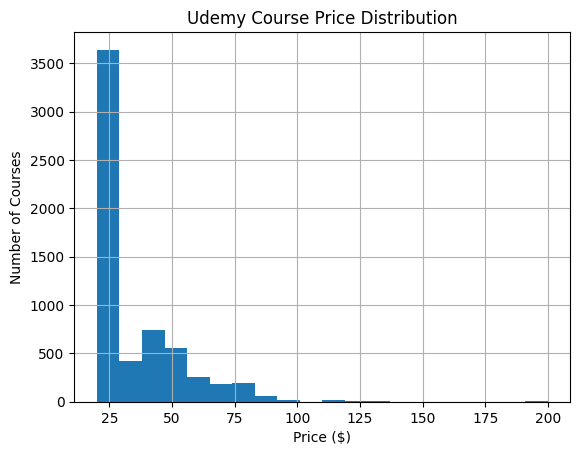

In [50]:
df["Price_value"] = df["Price"].str.extract(r'(\d+\.?\d*)').astype(float)

udemy = df[df["Platform"] == "Udemy"]

udemy["Price_value"].hist(bins=20)

plt.title("Udemy Course Price Distribution")
plt.xlabel("Price ($)")
plt.ylabel("Number of Courses")
plt.show()

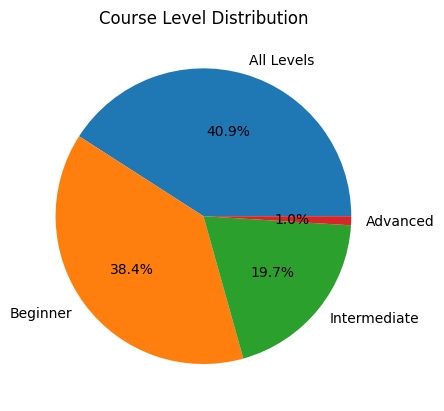

In [51]:
df["Level"] = df["Details"].str.extract(r'(Beginner|Intermediate|Advanced|All Levels)')

df["Level"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Course Level Distribution")
plt.ylabel("")
plt.show()

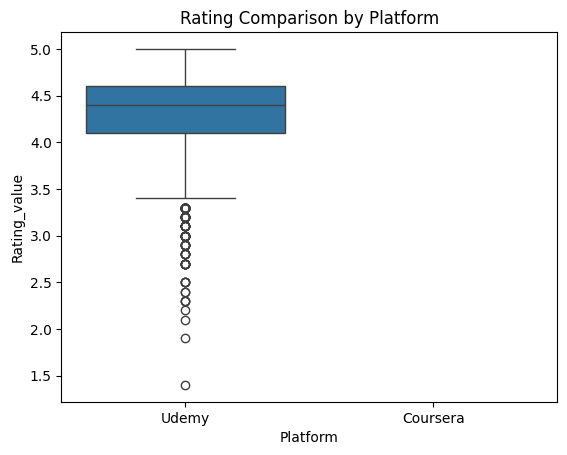

In [ ]:

sns.boxplot(x="Platform", y="Rating_value", data=df)

plt.title("Rating Comparison by Platform")
plt.show()

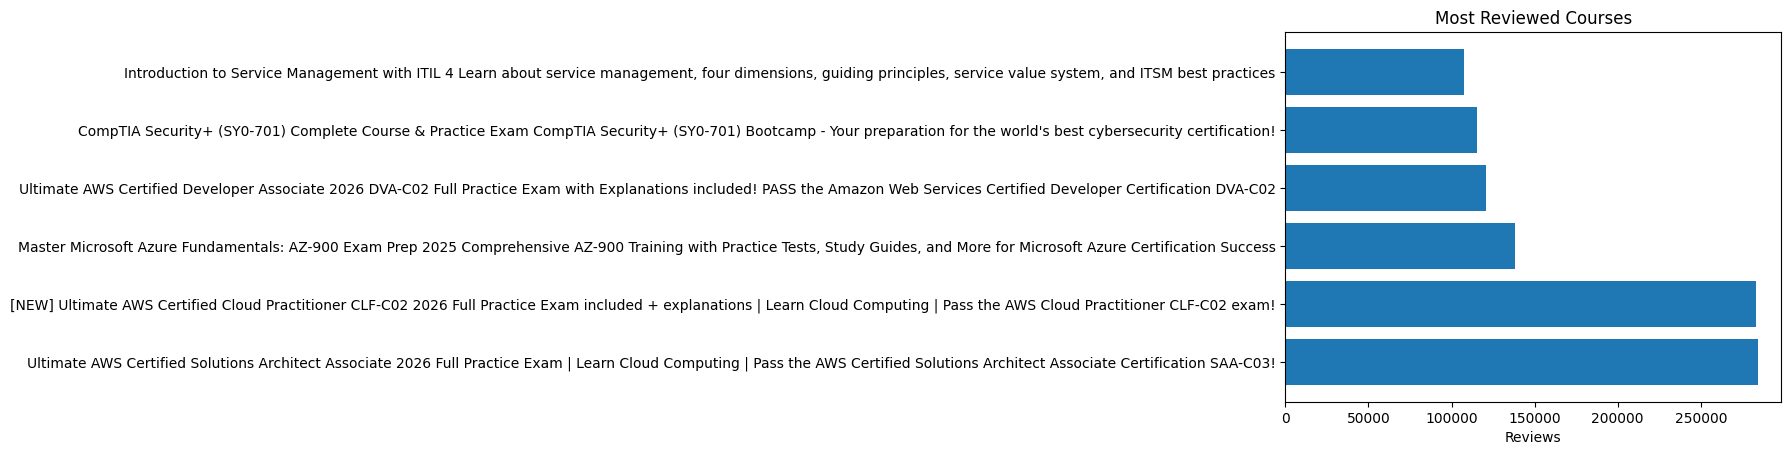

In [53]:
top = df.sort_values("Reviews_value", ascending=False).head(10)

plt.barh(top["Title"], top["Reviews_value"])

plt.title("Most Reviewed Courses")
plt.xlabel("Reviews")
plt.show()

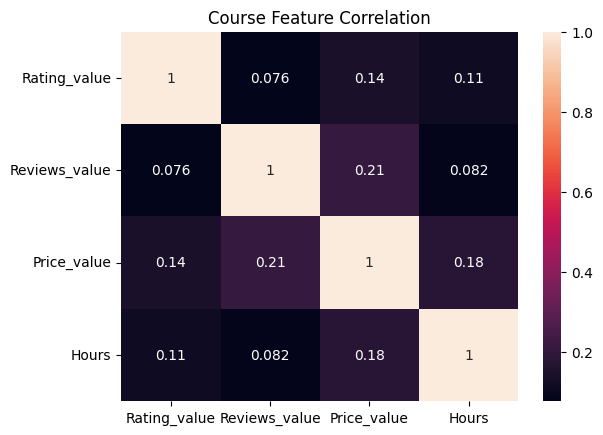

In [54]:
sns.heatmap(df[["Rating_value","Reviews_value","Price_value","Hours"]].corr(),
            annot=True)

plt.title("Course Feature Correlation")
plt.show()